# Tutorial 3: ODT Enables Regeneration Gene Discovery

This notebook performs an integrative cross-species analysis of planarian
regeneration-associated genes identified by the PFM-T model. Candidate genes
are first extracted from the planarian genome and queried against the NCBI
protein database via BLAST. The resulting homologues are then mapped to their
source organisms, assigned to taxonomic groups, and visualised through
phylogenetic trees, box plots of sequence identity, and a multi-entity
knowledge graph linking genes, proteins, species, and taxonomic clades.

The workflow proceeds through four stages: **(1)** gene sequence extraction
from the reference genome, **(2)** BLAST alignment parsing and filtering,
**(3)** taxonomic classification and phylogenetic tree construction, and
**(4)** integrative visualisation and knowledge graph assembly.

In [1]:
import pickle, random, colorsys, sys, time, os, csv, io, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from tqdm import tqdm
from collections import Counter
from io import StringIO
from openpyxl import Workbook, load_workbook
from Bio import SeqIO, Entrez, Phylo
from Bio.SeqRecord import SeqRecord
import gseapy as gp
from bioservices import UniProt

CODE_PATH = "/home/wwd/codebox/ODT-main/"
if CODE_PATH not in sys.path:
    sys.path.append(CODE_PATH)
from src.visualize import get_taxonomy, build_phylogenetic_tree3

Gene Sequence Extraction

The first stage extracts nucleotide sequences for candidate regeneration genes
from the planarian reference genome. `geneSelect()` reads the genome FASTA,
builds an in-memory dictionary mapping gene identifiers to sequences, and
writes the selected genes into smaller FASTA files suitable for batch BLAST
submission. `getGene()` parses the Excel spreadsheet mapping SMESG identifiers
to SMED transcript IDs and returns a deduplicated gene list. `getFiles()` is a
thin directory-traversal utility used throughout the notebook to aggregate
output files from staged pipeline runs.

In [2]:
def geneSelect(gene_list, fa_path='./gene_data/genome.fa', type_str='candidate_genes', gene_length=50):
    """Extract candidate gene sequences from the planarian genome FASTA and
    write them into smaller batch FASTA files for BLAST submission.
    """
    with open(os.path.join(CODE_PATH, 'results', 'Blast_result', 'gene_data2', 'genome.fa'), 'r') as f:
        fa_data = f.readlines()
    gene_dict = {}
    for data in fa_data:
        data = data.strip('\n')
        if '>' in data:
            gene_name = data.replace('>', '')
            gene_dict[gene_name] = ""
        else:
            gene_dict[gene_name] += data

    line_length = 50
    for i in range(0, len(gene_list), gene_length):
        batch = gene_list[i:i + gene_length]
        out_path = os.path.join(CODE_PATH, 'results', 'Blast_result', 'gene_data2', f'{type_str}{i}.fa')
        with open(out_path, 'w') as f:
            for gene in tqdm(batch):
                seq = gene_dict.get(gene, '')
                f.write(f'>{gene}\n')
                for k in range(0, len(seq), line_length):
                    f.write(seq[k:k + line_length] + '\n')


def getGene(gene_path=None):
    """Parse the GenesWithScoresMapped spreadsheet and return a deduplicated
    list of SMED transcript identifiers for all candidate regeneration genes.
    """
    if gene_path is None:
        gene_path = os.path.join(CODE_PATH, 'results', 'Blast_result', 'gene_data2', 'GenesWithScoresMapped.xlsx')
    data = pd.read_excel(gene_path, sheet_name='Sheet')
    gene_list = data['smed'].tolist()
    gene_list2 = []
    for gene in gene_list:
        gene = gene.replace('[', '').replace(']', '')
        for item in gene.split(','):
            gene_list2.append(item.strip(' ').strip("'"))
    return list(set(gene_list2))


def getFiles(target_dir):
    """Recursively collect absolute paths of all files under a directory."""
    file_paths = []
    for root, dirs, files in os.walk(target_dir):
        for file in files:
            file_paths.append(os.path.join(root, file))
    return file_paths

BLAST Alignment Parsing

BLAST results are parsed from two complementary output formats. The alignment
text file (produced by `Align_data_read_names`) is scanned for query identifiers
that produced at least one significant hit, yielding a coarse filter for
successfully mapped genes. The finer-grained `Align_data_extract` function
reads the structured CSV outputs — specifically the HitTable and Descriptions
files — and consolidates them into a unified record per accession. Records
passing the dual threshold of at least 40 % sequence identity and 50 % query
coverage are retained for downstream analysis; the remainder are discarded to
reduce noise from spurious low-quality matches.

In [3]:
def Align_data_read_names(Align_file=None):
    """Scan a BLAST alignment text file and return the set of query gene
    identifiers that yielded at least one significant alignment.
    """
    if Align_file is None:
        Align_file = os.path.join(CODE_PATH, 'results', 'Blast_result', 'gene_data2', 'RCCABKUX013-Alignment0.txt')
    with open(Align_file, 'r') as f:
        data = f.readlines()
    gene_data_list = []
    smed_id = '0'
    align_id = 0
    description_id = 0
    for data_str in data:
        data_str = data_str.strip('\n')
        if data_str == '':
            continue
        if 'Query #' in data_str:
            smed_id = data_str.split(' ')[2]
        elif 'Sequences producing significant alignments:' in data_str:
            align_id = 1
        elif 'Description' in data_str and 'Scientific' in data_str:
            description_id = 1
        elif align_id == 1 and description_id == 1:
            gene_data_list.append(smed_id)
        if 'Alignments:' in data_str:
            align_id = 0
            description_id = 0
    return list(set(gene_data_list))


def Align_data_extract(result_files):
    """Parse BLAST HitTable and Descriptions CSV files, merging them into a
    unified record per accession. Records passing the 40 % identity and 50 %
    query coverage thresholds are written to ``align_result_filtered.xlsx``.
    """
    file_id_list = []
    for file in result_files:
        basename = file.split('/')[-1].split('.')[0]
        file_id_list.append(basename.split('-')[0])
    file_id_list = list(set(file_id_list))

    Align_data_result_all = []
    index_id = [
        'Query ID', 'Accession ID', '% Identity (Per. Ident)', 'Alignment Length',
        'Mismatch Count', 'Gap Openings', 'Query Start', 'Query End',
        'Subject Start', 'Subject End', 'E-value', 'Bit Score',
        'Query Coverage', 'Frame', 'Additional Column'
    ]
    drop_list = []

    for file_id in tqdm(file_id_list):
        Align_data_result = {}
        hit_path = os.path.join(CODE_PATH, 'results', 'Blast_result', 'gene_data2', f'{file_id}-Alignment-HitTable.csv')
        with open(hit_path, 'r') as file:
            data = file.readlines()
        smed_align_result_dict = {}
        for data_list in data:
            data_list = data_list.strip('\n')
            if data_list == '':
                continue
            data_list = data_list.split(',')
            accession_id = data_list[index_id.index('Accession ID')]
            if (accession_id in smed_align_result_dict
                    and data_list[0] not in smed_align_result_dict[accession_id]):
                print(f'{accession_id} dropped')
                smed_align_result_dict[accession_id].append(data_list[0])
                drop_list.append([accession_id, smed_align_result_dict[accession_id]])
            else:
                Align_data_result[accession_id] = dict(zip(index_id, data_list))
                if accession_id not in smed_align_result_dict:
                    smed_align_result_dict[accession_id] = [data_list[0]]

        desc_path = os.path.join(CODE_PATH, 'results', 'Blast_result', 'gene_data2', f'{file_id}-Alignment-Descriptions.csv')
        with open(desc_path, 'r') as file:
            data = file.readlines()
        data_description_ids = data[0].strip('\n').strip(' ').split(',')
        data_description_ids[-1] = 'query_str'
        data_description_ids.append('Accession')
        for data_list in data[1:]:
            data_list = data_list.strip('\n')
            if data_list == '':
                continue
            reader = csv.reader(StringIO(data_list))
            parsed_data = list(reader)[0]
            if parsed_data == ['\t\t']:
                continue
            Accession_id = parsed_data[-1]
            if 'RJ31FHCX013-ALIGNMENT-CSV' in Accession_id:
                continue
            Accession_id = Accession_id.replace('"', '').split(',')[1].strip(')')
            parsed_data.append(Accession_id)
            for item in data_description_ids:
                if Accession_id in Align_data_result:
                    Align_data_result[Accession_id][item] = parsed_data[data_description_ids.index(item)]
                else:
                    Align_data_result[Accession_id] = {}
                    Align_data_result[Accession_id][item] = parsed_data[data_description_ids.index(item)]
            if Accession_id in Align_data_result:
                Align_data_result_all.append(Align_data_result[Accession_id])

    print(f'Total alignments parsed: {len(Align_data_result_all)}')
    drop_path = os.path.join(CODE_PATH, 'results', 'Blast_result', 'gene_data2', 'drop_all.txt')
    with open(drop_path, 'w') as file:
        for item in drop_list:
            file.write(f"{item[0]}  {'  '.join(item[1])}\n")

    wb = Workbook()
    ws = wb.active
    if len(Align_data_result_all) == 0:
        return
    key_list = list(Align_data_result_all[0].keys())
    ws.append(key_list)
    protein_ids = []
    for item in Align_data_result_all:
        data_list = [item.get(key_id, 'NA') for key_id in key_list]
        if float(item.get('Per. ident', 0)) >= 40 and float(item.get('Query Cover', '0').strip('%')) >= 50:
            ws.append(data_list)
            protein_ids.append(item['Accession'])
    wb.save(os.path.join(CODE_PATH, 'results', 'Blast_result', 'gene_data2', 'align_result_filtered.xlsx'))
    with open(os.path.join(CODE_PATH, 'results', 'Blast_result', 'gene_data2', 'protein.pkl'), 'wb') as file:
        pickle.dump(protein_ids, file)

Protein Sequence Retrieval and GenBank Export

Filtered protein accessions are fetched from NCBI via the Entrez API.
`make_protein_genebank()` retrieves the full GenBank record for each accession
and appends it to a cumulative GenBank file if a CDS feature is present.
`makeFASTA()` subsequently extracts either the translated protein sequence
(from the `translation` qualifier) or the underlying DNA coding sequence from
each CDS feature, writing the results to a multi-entry FASTA file for
downstream sequence analysis.

In [4]:
def make_protein_genebank(protein_ids, output_file=None):
    """Fetch GenBank records for a list of protein accessions via NCBI Entrez
    and append those containing CDS features to a cumulative GenBank file.
    """
    if output_file is None:
        output_file = os.path.join(CODE_PATH, 'results', 'Blast_result', 'gene_data2', 'protein_CDS.gb')
    from Bio import Entrez
    for protein_id in tqdm(protein_ids):
        try:
            handle = Entrez.efetch(db='protein', id=protein_id, rettype='gb', retmode='text')
            record = handle.read()
            handle.close()
            if 'CDS' in record:
                record_io = io.StringIO(record)
                parsed_record = SeqIO.read(record_io, 'genbank')
                if parsed_record:
                    with open(output_file, 'a') as gb_out:
                        gb_out.write(record)
        except Exception as e:
            print(f'Failed to fetch {protein_id}: {e}')


def makeFASTA(gb_file=None, output_file=None):
    """Extract protein or CDS sequences from a GenBank file and write them
    to a multi-entry FASTA file.
    """
    if gb_file is None:
        gb_file = os.path.join(CODE_PATH, 'results', 'Blast_result', 'gene_data2', 'protein_CDS.gb')
    if output_file is None:
        output_file = os.path.join(CODE_PATH, 'results', 'Blast_result', 'gene_data2', 'protein_sequences.fasta')
    with open(output_file, 'w') as fasta_out:
        with open(gb_file, 'r') as handle:
            for record in SeqIO.parse(handle, 'genbank'):
                for feature in record.features:
                    if feature.type == 'CDS':
                        if 'translation' in feature.qualifiers:
                            protein_seq = feature.qualifiers['translation'][0]
                            if protein_seq:
                                protein_record = SeqRecord(protein_seq, id=f'{record.id}_{feature.location}', description='')
                                SeqIO.write(protein_record, fasta_out, 'fasta')
                        else:
                            dna_seq = feature.extract(record.seq)
                            if dna_seq:
                                dna_record = SeqRecord(dna_seq, id=f'{record.id}_{feature.location}', description='')
                                SeqIO.write(dna_record, fasta_out, 'fasta')

Species Identification and Taxonomic Classification

`findAllSpecies()` parses the cumulative GenBank file, extracting the organism
annotation and accession identifier from each record and building a mapping
from species names to their associated protein accessions. `find_species_taxonomy()`
then queries the NCBI Taxonomy database via `get_taxonomy()` for each unique
species, extracting the higher-level taxonomic lineage and grouping species
into broad clades (e.g., snakes, salamanders, ray-finned fishes). This
taxonomic grouping forms the backbone of the phylogenetic tree and the
cross-species comparative analyses that follow.

In [5]:
def findAllSpecies(file_path=None):
    """Parse a GenBank file and return a list of unique species and a dict
    mapping each species to its associated protein accessions.
    """
    if file_path is None:
        file_path = os.path.join(CODE_PATH, 'results', 'Blast_result', 'gene_data2', 'protein_CDS.gb')
    species_list = []
    species_protein_list = {}
    for record in SeqIO.parse(file_path, 'genbank'):
        species = record.annotations.get('organism', 'Unknown')
        species_list.append(species)
        accession = record.id
        species_protein_list.setdefault(species, []).append(accession)
    return list(set(species_list)), species_protein_list


def find_species_taxonomy(species_list):
    """Query NCBI Taxonomy for each species and group them by higher-level
    taxonomic clade.
    """
    species_taxonomy = {}
    for species in tqdm(species_list):
        species_taxonomy[species] = get_taxonomy(species)
    taxonomy_dict = {}
    for species, taxonomy in species_taxonomy.items():
        clade = taxonomy.split('(')[1].strip(')') if '(' in taxonomy else taxonomy
        taxonomy_dict.setdefault(clade, []).append(species)
    print(f'Taxonomic groups identified: {list(taxonomy_dict.keys())}')
    return taxonomy_dict

Phylogenetic Tree and Cross-Species Visualisation

The remaining utility functions construct the visual and structural outputs of
the cross-species analysis. `get_species_groups_dict()` loads the manually
curated species-to-clade edge table. `make_echarts_code()` assembles a
hierarchical tree structure from these edges and serialises it as JSON for
interactive visualisation. `makeBox_species_ident()` produces a box plot of
BLAST percent identity values stratified by taxonomic group, revealing
which clades harbour the strongest sequence conservation with planarian
regeneration genes. `analyse_per_identBygenes()` links SMESG-level scores
with SMED-level alignment data for per-gene visualisation. `makeKnowledgeGraph()`
integrates all entities — candidate genes, SMED transcripts, matched proteins,
host species, and taxonomic clades — into a unified knowledge graph exported
as a set of CSV node and edge tables for import into graph databases or
network analysis tools.

In [6]:
def get_species_groups_dict(edge_csv_path=None):
    """Load the species-to-taxonomic-group edge mapping from a CSV file."""
    if edge_csv_path is None:
        edge_csv_path = os.path.join(CODE_PATH, 'results', 'Blast_result', 'gene_data2', 'edges.csv')
    with open(edge_csv_path, 'r') as f:
        edge_data = f.readlines()
    species_groups_dict = {}
    for edge in edge_data:
        edge = edge.strip('\n').split(',')
        species_groups_dict[edge[0]] = edge[1]
    return species_groups_dict


def make_echarts_code(species_protein_list, edge_csv_path=None):
    """Build a hierarchical tree of species and taxonomic groups from edge
    data, annotated with protein counts per node, and serialise as JSON.
    """
    if edge_csv_path is None:
        edge_csv_path = os.path.join(CODE_PATH, 'results', 'Blast_result', 'gene_data2', 'edges.csv')
    edges = []
    with open(edge_csv_path, 'r') as f:
        edge_data = f.readlines()
    for data in edge_data[1:]:
        parts = data.strip('\n').split(',')
        edges.append([parts[1], parts[0]])

    node_map = {'root': {'name': 'root', 'children': []}}
    for edge in reversed(edges):
        source, target = edge[0], edge[1]
        if source == 'lizards' or target == 'lizards':
            continue
        if source not in node_map:
            node_map[source] = {'name': source, 'children': []}
        if target not in node_map:
            node_map[target] = {'name': target}
        if '&' in target and source != 'root':
            if (node_map[target] not in node_map['root']['children']
                    and len(node_map[target].get('children', [])) != 0):
                node_map['root']['children'].append(node_map[target])
            continue
        else:
            node_map[source]['children'].append(node_map[target])

    for node in species_protein_list:
        if node in node_map:
            node_map[node]['value'] = len(species_protein_list[node])

    def getvalue(n):
        if n['name'] in species_protein_list:
            return n.get('value', 0)
        return sum(getvalue(child) for child in n.get('children', []))

    for node in node_map:
        if node in node_map and 'children' in node_map[node]:
            node_map[node]['value'] = getvalue(node_map[node])

    sorted_node_map = {k: v for k, v in sorted(node_map.items(), key=lambda item: item[1].get('value', 0))}
    sorted_node_map['root']['name'] = 'All_Proteins'
    print(json.dumps(sorted_node_map.get('root', {})))


def makeBox_species_ident():
    """Generate a box plot of BLAST percent identity values stratified by
    taxonomic group.
    """
    species_groups_dict = get_species_groups_dict()
    workbook = load_workbook(os.path.join(CODE_PATH, 'results', 'Blast_result', 'gene_data2', 'align_result.xlsx'))
    sheet = workbook[workbook.sheetnames[0]]
    group_per_idents = {}
    for row in sheet.iter_rows(values_only=True):
        row_list = list(row)
        if row_list[16] == 'Scientific Name' or row_list[16] not in species_groups_dict:
            continue
        group = species_groups_dict[row_list[16]]
        group_per_idents.setdefault(group, []).append(float(row_list[2]))

    group_order = list(group_per_idents.keys())
    labels, values = [], []
    for group, value_list in group_per_idents.items():
        value_list = [v for v in value_list if float(v) > 45]
        labels.extend([group] * len(value_list))
        values.extend(value_list)

    df = pd.DataFrame({'Group': labels, 'Value': pd.to_numeric(values, errors='coerce')})
    cmap = plt.get_cmap('Set3')
    palette = {group: cmap(i / len(group_order)) for i, group in enumerate(group_order)}

    plt.figure(figsize=(16, 12))
    sns.boxplot(x='Group', y='Value', data=df, order=group_order, palette=palette)
    plt.xticks([])
    plt.tick_params(axis='x', bottom=False, top=False, labelbottom=False)
    handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=24) for color in palette.values()]
    plt.legend(handles=handles, labels=group_order, bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=28, frameon=False)
    plt.xlabel('Taxonomy Groups', fontsize=30)
    plt.ylabel('Per.Ident Value', fontsize=30)
    for spine in plt.gca().spines.values():
        spine.set_linewidth(2)
    plt.tick_params(axis='y', labelsize=24)
    plt.tight_layout()
    plt.savefig(os.path.join(CODE_PATH, 'results', 'Blast_result', 'Taxonomy-Based-Protein-Per-Ident-Distribution.png'), dpi=300)
    plt.show()


def analyse_per_identBygenes():
    """Merge SMESG-level gene scores with SMED-level BLAST alignment data
    for per-gene percent identity visualisation.
    """
    species_groups_dict = get_species_groups_dict()
    workbook = load_workbook(os.path.join(CODE_PATH, 'results', 'Blast_result', 'gene_data2', 'align_result.xlsx'))
    sheet = workbook[workbook.sheetnames[0]]
    smed_align_result = {}
    for row in sheet.iter_rows(values_only=True):
        row_list = list(row)
        if row_list[16] == 'Scientific Name' or row_list[16] not in species_groups_dict:
            continue
        smed_align_result.setdefault(row_list[0], []).append({
            'Accession_id': row_list[1], 'Per.Ident': row_list[2],
            'species': row_list[16], 'group': species_groups_dict[row_list[16]]
        })
    workbook = load_workbook(os.path.join(CODE_PATH, 'results', 'Blast_result', 'gene_data2', 'GenesWithScoresMapped.xlsx'))
    return smed_align_result


def makeKnowledgeGraph():
    """Integrate candidate genes, SMED transcripts, matched proteins, host
    species, and taxonomic clades into a unified knowledge graph exported as
    CSV node and edge tables.
    """
    data = pd.read_excel(os.path.join(CODE_PATH, 'results', 'Blast_result', 'gene_data2', 'GenesWithScoresMapped.xlsx'), sheet_name='Sheet')
    columns = data.columns.tolist()
    data_filtered = data[columns[:4]]
    gene_smed_list = []
    candidate_genes = {}
    for gene_dict in data_filtered.to_dict(orient='records'):
        gene_smed = gene_dict['smed'].strip('[').strip(']').replace("'", '').split(',')
        gene_dict['smed'] = gene_smed
        candidate_genes[gene_dict['Gene']] = dict(gene_dict)
        for smed in gene_smed:
            gene_smed_list.append({'id': gene_dict['Gene'], 'smed': smed.strip(' ')})

    pd.DataFrame(candidate_genes.values()).to_csv(os.path.join(CODE_PATH, 'results', 'Blast_result', 'candidate_genes.csv'), index=False)
    pd.DataFrame(gene_smed_list).to_csv(os.path.join(CODE_PATH, 'results', 'Blast_result', 'gene_smeds_edge.csv'), index=False)
    print('Knowledge graph exported to results/Blast_result/')




## Step 1: Species discovery and taxonomy
`findAllSpecies()` parses thecumulative GenBank file produced by the BLAST pipeline, extracting the set of unique source organisms and their associated protein accessions.
`find_species_taxonomy()` then resolves each organism to its higher-level taxonomic clade via NCBI Taxonomy queries.

In [7]:
# Stage 1 — Discover species from GenBank records and classify taxonomically.
species_list, species_protein_list = findAllSpecies()
taxonomy_dict = find_species_taxonomy(species_list)

  0%|          | 0/50 [00:00<?, ?it/s]/home/wwd/anaconda3/envs/geneformer/lib/python3.8/site-packages/Bio/Entrez/__init__.py:694: UserWarning: 
            Email address is not specified.

            To make use of NCBI's E-utilities, NCBI requires you to specify your
            email address with each request.  As an example, if your email address
            is A.N.Other@example.com, you can specify it as follows:
               from Bio import Entrez
               Entrez.email = 'A.N.Other@example.com'
            In case of excessive usage of the E-utilities, NCBI will attempt to contact
            a user at the email address provided before blocking access to the
            E-utilities.
  warnings.warn(
100%|██████████| 50/50 [00:52<00:00,  1.04s/it]

Taxonomic groups identified: ['lizards & snakes', 'salamanders', 'snakes', 'frogs & toads', 'primates', 'ray-finned fishes', 'flatworms', 'rodents', 'sea cucumbers']


## Step 2: Phylogenetic tree construction
Species counts are tabulated and `build_phylogenetic_tree3()` renders a directed acyclic graph of taxonomic
relationships, with node sizes proportional to the number of matched proteins
per species or clade.

In [8]:
# Stage 2 — Build and render the phylogenetic tree.
species_counts = dict(Counter(species_list))
build_phylogenetic_tree3(taxonomy_dict, species_counts)

{'flatworms': (0.8941176470588236, 0.10196078431372549, 0.10980392156862745), 'rodents': (0.21568627450980393, 0.49411764705882355, 0.7215686274509804), 'toads': (0.30196078431372547, 0.6862745098039216, 0.2901960784313726), 'ray-finned fishes': (0.596078431372549, 0.3058823529411765, 0.6392156862745098), 'lizards & snakes': (1.0, 0.4980392156862745, 0.0), 'frogs & toads': (1.0, 1.0, 0.2), 'lizards': (0.6509803921568628, 0.33725490196078434, 0.1568627450980392), 'primates': (0.9686274509803922, 0.5058823529411764, 0.7490196078431373), 'snakes': (0.6, 0.6, 0.6), 'frogs': (0.8941176470588236, 0.10196078431372549, 0.10980392156862745), 'sea cucumbers': (0.21568627450980393, 0.49411764705882355, 0.7215686274509804), 'salamanders': (0.30196078431372547, 0.6862745098039216, 0.2901960784313726), 'root': (0.596078431372549, 0.3058823529411765, 0.6392156862745098)}


<Figure size 1200x800 with 0 Axes>

## Step 3: Cross-species visualisation.
`make_echarts_code()` serialises
the species-to-clade hierarchy as interactive JSON. `makeBox_species_ident()`
produces a box plot of BLAST percent identity stratified by taxonomic group,
highlighting which clades exhibit the strongest sequence conservation with
planarian regeneration genes. `make_line_box()` generates per-gene box plots
of protein similarity scores.

{"name": "All_Proteins", "children": [{"name": "sea cucumbers", "children": [{"name": "Apostichopus japonicus", "value": 19}, {"name": "Holothuria leucospilota", "value": 32}], "value": 51}, {"name": "rodents", "children": [{"name": "Rattus norvegicus", "value": 201}, {"name": "Mus musculus", "value": 287}], "value": 488}, {"name": "flatworms", "children": [{"name": "Schmidtea mediterranea", "value": 6}], "value": 6}, {"name": "ray-finned fishes", "children": [{"name": "Cololabis saira", "value": 101}, {"name": "Oryzias javanicus", "value": 51}, {"name": "Oryzias melastigma", "value": 162}, {"name": "Oryzias latipes", "value": 139}, {"name": "Danio rerio", "value": 137}], "value": 590}, {"name": "primates", "children": [{"name": "Homo sapiens", "value": 450}], "value": 450}, {"name": "toads"}, {"name": "frogs"}, {"name": "frogs & toads", "children": [{"name": "Xenopus laevis", "value": 238}], "value": 238}, {"name": "salamanders", "children": [{"name": "Ambystoma mexicanum", "value": 9

/tmp/ipykernel_819100/2545488836.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group', y='Value', data=df, order=group_order, palette=palette)


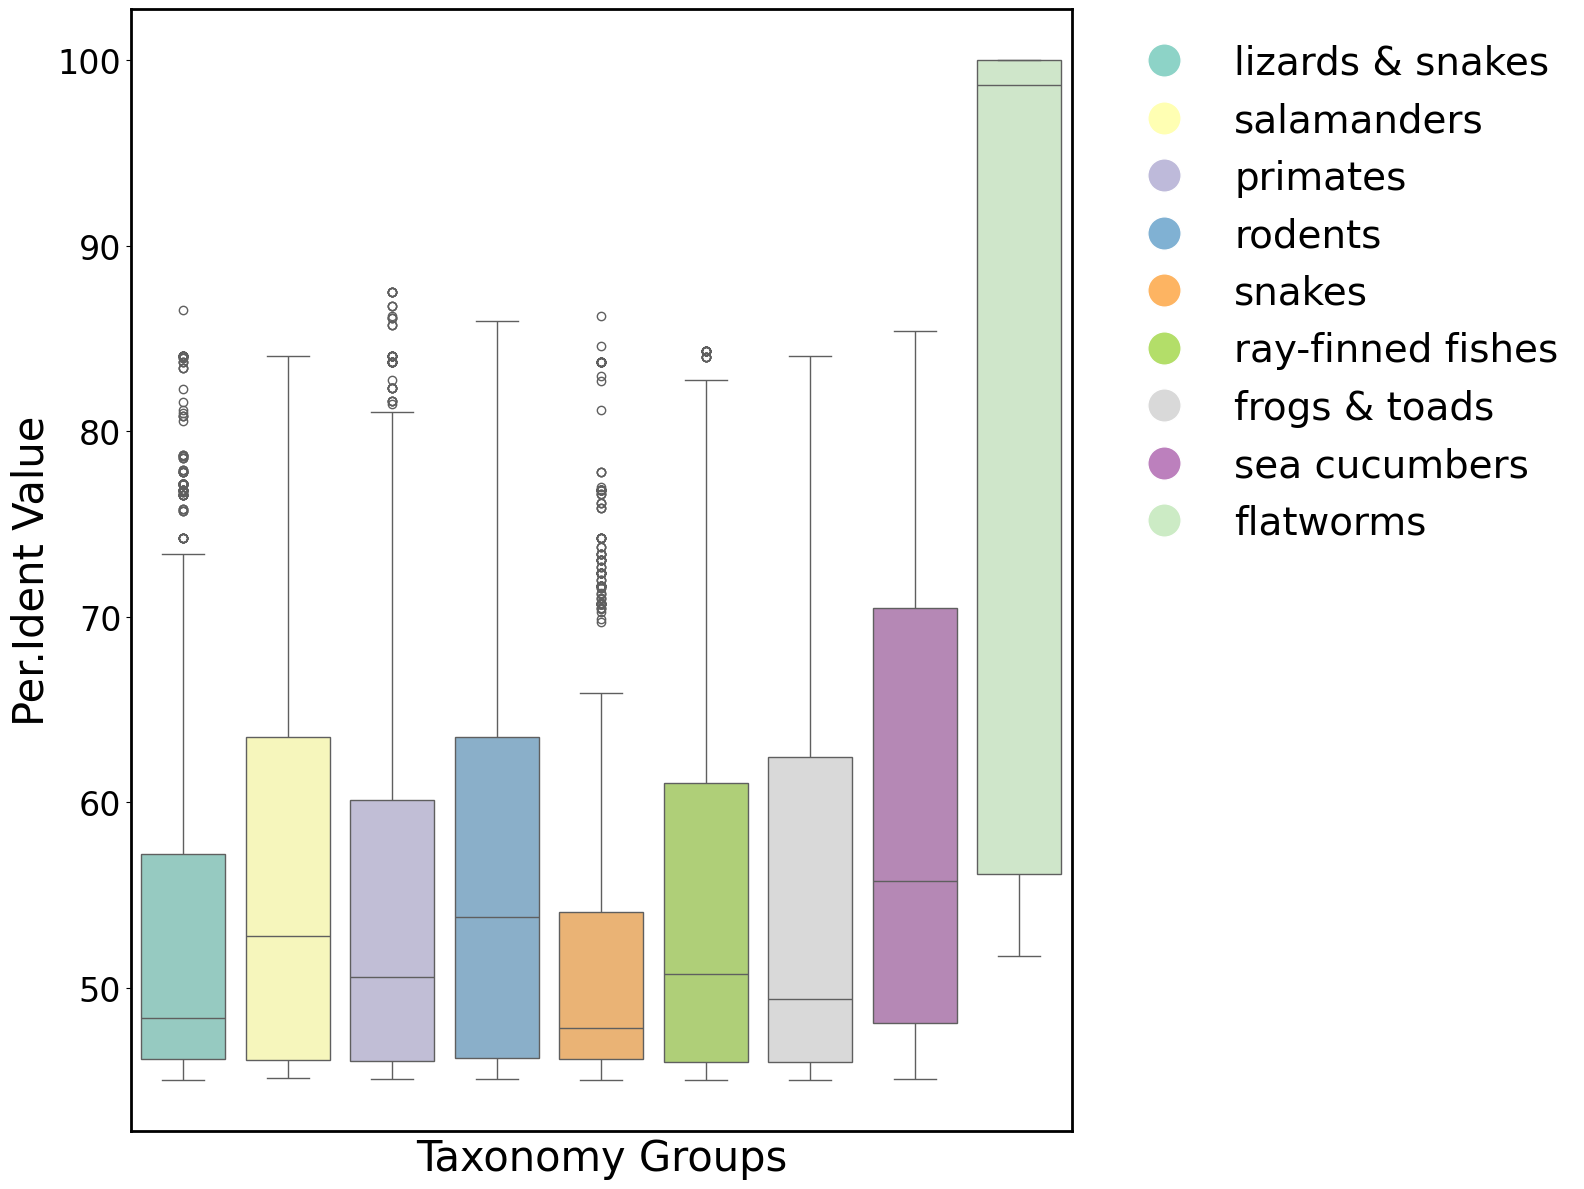

In [9]:
# Stage 3 — Cross-species visualisation.
species_list, species_protein_list = findAllSpecies(
    file_path=os.path.join(CODE_PATH, 'results', 'Blast_result', 'gene_data2', 'protein_CDS.gb'))
make_echarts_code(species_protein_list)
makeBox_species_ident()

## Step 4: Knowledge graph assembly
`makeKnowledgeGraph()` integrates all
entities — candidate regeneration genes, their SMED transcripts, matched
homologous proteins, host species, and taxonomic clades — into a unified
multi-entity graph exported as CSV node and edge tables for downstream network
analysis or import into graph database systems.

In [10]:
# Stage 4 — Assemble and export the multi-entity knowledge graph.
makeKnowledgeGraph()

Knowledge graph exported to results/Blast_result/
